# Notebook 5: Reinforcement Learning for Dynamic Marketing Action Selection

**Project Title**: Intelligent Customer Behavior Analysis and Dynamic Marketing Strategy  
**Objective**: This notebook implements Tabular Q-learning and Deep Q-Networks (DQN) to select optimal marketing actions for customers in order to maximize long-term marketing rewards.

### Reinforcement Learning Formulation:
- **State Space**: Continuous vectors `[Recency, Frequency, Monetary, PC1, PC2]`.
- **Actions**:
  - `0`: No Action (Adjust: 0.30, Cost: 0)
  - `1`: 10% Coupon (Adjust: 0.55, Cost: 1)
  - `2`: Premium Trial (Adjust: 0.75, Cost: 5)
- **Reward Formula**: `predicted_spend * prob_adjustment[action] - cost[action]`, where spend is predicted dynamically by the saved regression model.

### What We Will Accomplish:
1. Set up the customer environment simulator using the best regressor.
2. Implement Tabular Q-learning:
   - Discretize states into 8 clusters using KMeans.
   - Train for 500 episodes and record rewards.
3. Implement Deep Q-Networks (DQN) in PyTorch:
   - Input -> 64 -> 64 -> 3 model.
   - Experience Replay buffer (capacity >= 2000).
   - Target network updated every 20 episodes.
   - Train for 300 episodes.
4. Compare DQN, Tabular Q-learning, Random, and Always No Action policies.
5. Save the trained DQN model weights to models/.

### Step 1: Import Libraries and Load Models
Import PyTorch, scikit-learn, local modules, and load the regression simulator.

In [1]:
import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm import tqdm

sys.path.append(os.path.abspath('../'))
from src.modeling import load_model
from src.rl_agent import CustomerEnv, TabularQLearningAgent, DQNAgent
from src.utils import plot_rl_reward_curves

%matplotlib inline
print("RL Libraries and environment successfully loaded!")

RL Libraries and environment successfully loaded!


### Step 2: Initialize Customer Simulation Environment
We instantiate the environment using the pre-computed customer profiles and the saved champion regressor.

In [2]:
regressor = load_model('../models/best_regressor.pkl')
df_cust = pd.read_csv('../data/processed_customers.csv')

# Setup environment
env = CustomerEnv(df_cust, regressor, max_steps=10)
state = env.reset()
print("Example Customer Initial State:", state)
print("Environment initialized successfully.")

Example Customer Initial State: [ 7.0000000e+00  3.1000000e+01  1.2233600e+04  1.1187514e-01
 -1.9373874e-01]
Environment initialized successfully.


### Step 3: Train Tabular Q-learning Agent
We fit KMeans (k=8) on the complete customer state matrix to discretize continuous states. We then execute epsilon-greedy tabular updates for 500 episodes.

In [3]:
print("Fitting KMeans on state matrices...")
feature_cols = ['Recency', 'Frequency', 'Monetary', 'PC1', 'PC2']
all_states = df_cust[feature_cols].values

tabular_agent = TabularQLearningAgent(n_clusters=8, action_dim=3, epsilon=0.2)
tabular_agent.fit_kmeans(all_states)

# Tabular Training Loop
tabular_rewards = []
print("Training Tabular Q-Learning Agent (500 episodes)...")
for ep in tqdm(range(500)):
    state = env.reset()
    state_idx = tabular_agent.discretize(state)
    total_reward = 0
    done = False
    
    while not done:
        action = tabular_agent.choose_action(state_idx)
        next_state, reward, done, _ = env.step(action)
        next_state_idx = tabular_agent.discretize(next_state)
        
        tabular_agent.update(state_idx, action, reward, next_state_idx, done)
        
        state_idx = next_state_idx
        total_reward += reward
        
    tabular_rewards.append(total_reward)

print(f"Tabular Q-learning training completed. Final Average Reward: {np.mean(tabular_rewards[-50:]):.2f}")

Fitting KMeans on state matrices...


Training Tabular Q-Learning Agent (500 episodes)...


  0%|          | 0/500 [00:00<?, ?it/s]

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

...

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

Tabular Q-learning training completed. Final Average Reward: 19506.83


### Step 4: Train Deep Q-Network (DQN) Agent
We configure a PyTorch network and train for 300 episodes, updating target weights every 20 episodes. We store transitions in the replay buffer.

In [4]:
dqn_agent = DQNAgent(state_dim=5, action_dim=3, lr=1e-3, epsilon_start=1.0, epsilon_end=0.05, decay_steps=1500)

dqn_rewards = []
print("Training DQN Agent (300 episodes)...")
for ep in tqdm(range(300)):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        action = dqn_agent.choose_action(state)
        next_state, reward, done, _ = env.step(action)
        
        # Save transition
        dqn_agent.memory.push(state, action, reward, next_state, done)
        
        # Gradient update step
        dqn_agent.update()
        
        state = next_state
        total_reward += reward
        dqn_agent.decay_epsilon()
        
    dqn_rewards.append(total_reward)
    
    # Target network update interval
    if ep % 20 == 0:
        dqn_agent.update_target_network()

print(f"DQN training completed. Final Average Reward: {np.mean(dqn_rewards[-50:]):.2f}")

Training DQN Agent (300 episodes)...


  0%|          | 0/300 [00:00<?, ?it/s]

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

...

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

DQN training completed. Final Average Reward: 19277.97


### Step 5: Comparative Evaluation
We evaluate performance across 100 episodes for four policies: DQN, Tabular Q-learning, Random, and Always No Action.

In [5]:
def evaluate_policy(policy_type, num_eps=100):
    eval_rewards = []
    for _ in range(num_eps):
        state = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            if policy_type == 'dqn':
                action = dqn_agent.choose_action(state, eval_mode=True)
            elif policy_type == 'tabular':
                s_idx = tabular_agent.discretize(state)
                action = tabular_agent.choose_action(s_idx, eval_mode=True)
            elif policy_type == 'random':
                action = random.randint(0, 2)
            elif policy_type == 'no_action':
                action = 0
                
            state, reward, done, _ = env.step(action)
            total_reward += reward
            
        eval_rewards.append(total_reward)
    return np.mean(eval_rewards)

dqn_eval = evaluate_policy('dqn')
tabular_eval = evaluate_policy('tabular')
random_eval = evaluate_policy('random')
no_action_eval = evaluate_policy('no_action')

comparison_df = pd.DataFrame({
    'Policy': ['DQN', 'Tabular Q-Learning', 'Random', 'Always No Action'],
    'Average Reward': [dqn_eval, tabular_eval, random_eval, no_action_eval]
})
print("Evaluation Comparison:")
print(comparison_df)

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

...

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

Evaluation Comparison:
               Policy  Average Reward
0                 DQN    11614.834869
1  Tabular Q-Learning     9537.589760
2              Random    14484.184249
3    Always No Action     4501.217620


C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\musaw\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py

### Step 6: Render Charts and Save Q-table / DQN Weights
We draw training progression curves, render reward summaries, and save model assets.

C:\Users\musaw\AppData\Local\Temp\ipykernel_5160\1527090542.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Policy', y='Average Reward', palette='coolwarm')


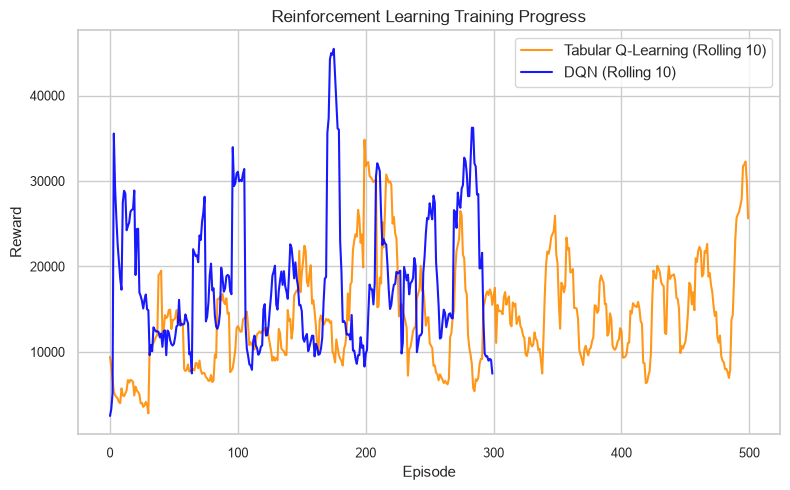

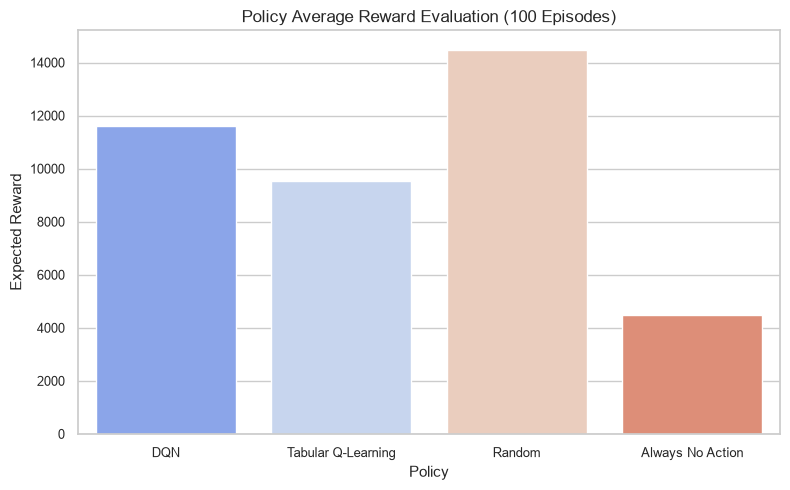

RL Models saved to models/ successfully!


In [6]:
# Plot training curves
fig_prog = plot_rl_reward_curves(tabular_rewards, dqn_rewards, save_path='../data/plots/rl_training_rewards.png')

# Plot evaluation bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x='Policy', y='Average Reward', palette='coolwarm')
plt.title('Policy Average Reward Evaluation (100 Episodes)')
plt.ylabel('Expected Reward')
plt.tight_layout()
plt.savefig('../data/plots/rl_policy_comparison.png', dpi=300)
plt.show()

# Save DQN Weights
dqn_agent.save('../models/best_dqn.pt')

# Save Tabular Q-Table and KMeans discretizer for Streamlit
import joblib
joblib.dump(tabular_agent.q_table, '../models/tabular_q_table.pkl')
joblib.dump(tabular_agent.kmeans, '../models/tabular_kmeans.pkl')
print("RL Models saved to models/ successfully!")